**Read README.md first.**

author: Xu Chen, 2021.08

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import numpy.fft as fft
import sys
sys.path.append('/data/inspur_disk01/userdir/ucas_students/xuc/FAST/G15/test_pipe/')
from util import *
from copy import deepcopy
from tqdm import tqdm

In [2]:
subname = '../data6/sub/M31_SnapShot_6_snapshot-M06_W-20210730-specs_T-bld.hdf5'
sub = h5py.File(subname,'r')

# example polar yy

以偏振yy的前2000条为例

In [3]:
data = get_data(sub,polar='yy')[:][:2000]
freq = sub['freq'][:]
is_on = sub['is_on'][:][:2000]

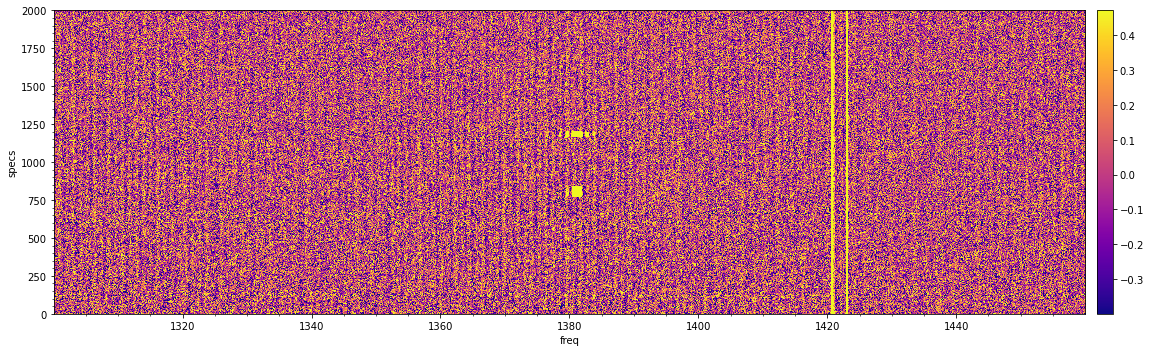

In [4]:
plot_waterfall(sub,data,per_vmin_max=.90,figsize=(18,5),cmap = 'plasma')

# time RFI


* --time_rfi：标记时域上突然出现的RFI，根据占据的频率长度，分为short-freq/long-freq。
    对该频率区间内的所有谱线做频率方向的平均后，画出一维的图。如果有`--lf`或`--sf`，可以省略`--time_rfi`

* --sf
* --sf_frange: 一个典型的1～2MHz宽时域RFI，经常出现在1380～1382MHz。
* --sf_file: 或者可以指定一个二维数组的npy文件路径，在里面循环找，例如以下是只找时域RFI:
    ```
    time_rfi_file = '/data/inspur_disk01/userdir/ucas_students/xuc/FAST/G15/newG15/time_rfi_list.npy'
    python cli_markRFI.py $subname --outdir ./data \
            --sf \
            --sf_file $time_rfi_file --sf_times 1.8 --sf_thr 0 --sf_rfi_last 20 --sf_T_thr_times 3 \
            --plot --ylim -1 5 --vmin_max -.05 .05 -f  || exit 1 

    INFO: Looking for short-freq time RFI in [1378 1384] ... [markRFI]
    Found :D
    INFO: Looking for short-freq time RFI in [1310 1315] ... [markRFI]
    Found :D
    INFO: Looking for short-freq time RFI in [1320 1325] ... [markRFI]
    Found :D
    Finish
    ```
* --sf_frange_step:如果sf_frange和sf_file不指定，将以这个step(MHz)在频率上循环，对每个区间找一次时域RFI
    ```
    python cli_markRFI.py $subname \
            --outdir $outdir \
            --mw_frange 1420.3 1423.3 --sf_frange_step 20 \
            --sf --sf_times 3 --sf_thr 0 --sf_rfi_last 10 --sf_T_thr_times 3 \
            --lf --lf_frange 1400 1450 --lf_times 1.5 --lf_thr 0 --lf_rfi_last 50 --lf_ext 10 \
            --plot --ylim -.5 .5 --vmin_max -.05 .05 -f  || exit 1 
    ```
* --sf_times: 大于各谱线之中，中值的10倍，初步认为异常
* --sf_thr: 边缘处与附近值的差是中值的倍数，找出时间方向的边缘处陡峭的
* --sf_rfi_last: 持续出现的谱线数
* --sf_T_thr_times: 选定区域后，大于温度阈值的被标记
* --sf_ext: 选定区域后，扩展边缘

* --lf
* --lf_beams: 已知出现大卫星干扰的波束，其他不搜寻。如果不设置就对所有波束搜寻。
* --lf_frange: 大范围频率
* --lf_times: 大于各谱线之中，中值1.5倍，初步认为异常.
* --lf_thr: 不需要边缘陡峭，所以设为0
* --lf_rfi_last: 持续出现的谱线数
* --lf_ext: 选定区域后，扩展边缘

输出文件名含tr

寻找时域RFI之前，先计算一下谱线的RMS。这里选取了比较平坦的1390～1400mhz，选择一个合适的平滑sigma。

In [5]:
import mpl_interactions.ipyplot as iplt

In [6]:
%matplotlib ipympl
spec = deepcopy(data[0,:])
def test_gauss(freq,sigma):
    from hifast.utils.misc import smooth1d
    sm = smooth1d(spec,method='gaussian',sigma=sigma)
    return sm

fig,ax = plt.subplots(figsize=(10,2))
iplt.plot(freq,spec,label = 'ori')
controls = iplt.plot(freq, test_gauss,  sigma=np.arange(2, 20, 1),xlim = [1380,1430],
                     ylim=[-1,1.2],color = 'C1',label='smooth')
iplt.title("sigma is {sigma:.2f}", controls=controls['sigma'])
plt.legend()
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

In [7]:
from markRFI import mask_time_rfi,real_rms
RMS = real_rms(spec,freq,sigma=6,rms_vrange=[1390,1400])

对于一个短横条样子的时域RFI，使用前面的sf参数控制。

| --sf para | function para | 建议 |
|---|---|---|
| --sf_frange | frange | 一般是1380mhz附近有这种rfi，但不全是。推荐设置--sf_frange_step 20或40等进行循环 |
| --sf_times | times | 根据下图虚线决定阈值是中值的多少倍，这里我使用的3倍 |
| --sf_thr | thr | 有时这种rfi边界平缓，一般比较陡峭，可以试验看看 |
| --sf_rfi_last | rfi_width_lim | 根据rfi时域宽度判断，对于下面右边的rfi wide<=30 |
| --sf_T_thr_times | T_thr_times | mask的范围，根据下面瀑布图的效果增减 |
| --sf_ext | ext_add | 一般不用扩展，设为0 |

In [8]:
%matplotlib inline

INFO: Looking for short-freq time RFI in [1370, 1390] ... [markRFI]
Found :D
Finish


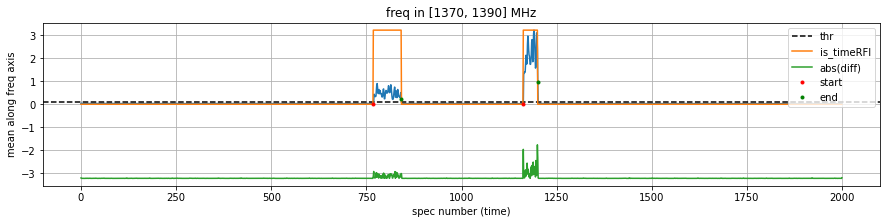

In [9]:
s_rfi = mask_time_rfi(data,freq,T_thr_times = 3, rtype = 'short-freq',frange =[1370,1390],times = 3,thr = 1,
                      ext_add=0,rfi_width_lim = 30,plot = True,RMS=RMS)

In [10]:
s_rfi = mask_time_rfi(data,freq,T_thr_times = 3, rtype = 'short-freq',frange =[1300,1320],times = 3,thr = 0,
                      ext_add=0,rfi_width_lim = 10,plot = True,RMS=RMS)

No short-freq time rfi is found.
Finish


In [15]:
T = deepcopy(data)
T[s_rfi] = np.nan

确认T_thr_times是否能将RFI基本mask掉，太低会mask其他东西(比如驻波)

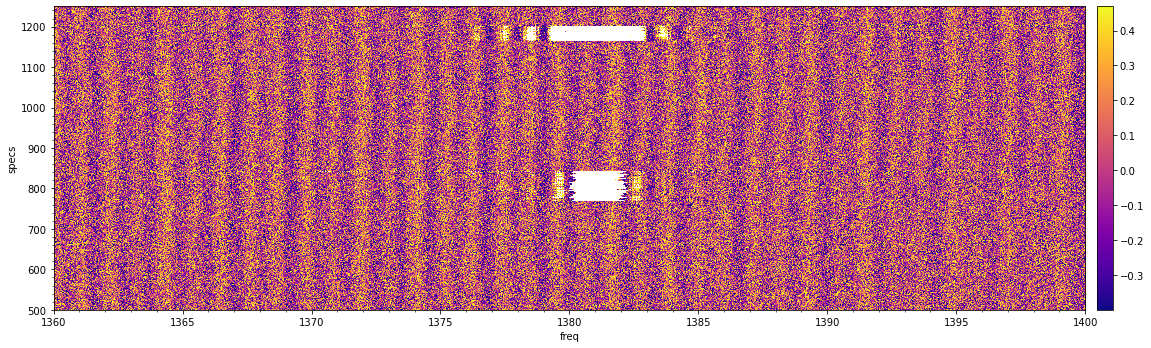

In [16]:
plot_waterfall(sub,T,per_vmin_max=.90,figsize=(18,5),cmap = 'plasma',xylim = (1360,1400,500,1250))

通过类似的lf参数，也可以找出很强的长频率时域RFI

| --lf para | function para | 建议 |
|---|---|---| 
| --lf_frange | frange | [1400,1460]或者避开银河系[1421,1460]，RFI集中的频率 |
| --lf_times | times | 根据图片确定阈值倍数|
| --lf_thr | thr | 由于是平缓的边界，直接设为0|
| --lf_rfi_last | rfi_width_lim | 一般宽度300～500以上，如果刚好在边缘有些难搞，可能只有50以上|
| --lf_ext | ext_add | 适当扩展，但是会多扔谱线，建议0～2|

INFO: Looking for long-freq time RFI ... [markRFI]
No long-freq time rfi is found.


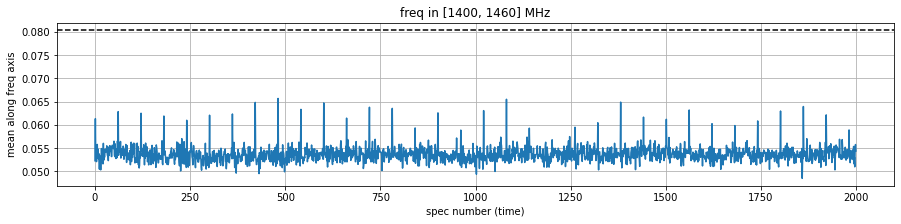

In [11]:
l_rfi = mask_time_rfi(data,freq, rtype = 'long-freq',frange =[1400,1460],times = 1.5,thr = 0,
                      ext_add=0,rfi_width_lim = 50,plot = True,RMS=RMS)

跑标记RFI程序
这里一并搜索了lf，不过这次数据里没有这种RFI
```
python cli_mark—_tRFI.py $fname \
        --outdir $outdir \
        --mw_frange 1420.3 1423.3 --sf_frange_step 20 \
        --sf --sf_times 3 --sf_thr 0 --sf_rfi_last 10 --sf_T_thr_times 3 \
        --lf --lf_frange 1400 1460 --lf_times 1.5 --lf_thr 0 --lf_rfi_last 50 --lf_ext 0 \
        --plot --ylim -.5 .5 --vmin_max -.05 .05 -f  || exit 1 
```
加载rfi文件

In [12]:
rfiname = '../data6/rfi/M31_SnapShot_6_snapshot-M03_W-20210730-specs_T-bld-tr.hdf5'
rfi = h5py.File(rfiname,'r')
is_rfi = rfi['is_rfi'][:][:2000]

# MW range
有MW、M31的区域，下面会被替代为驻波

(1420.3, 1423.3)

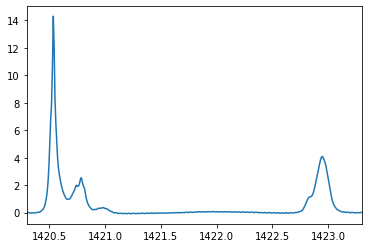

In [13]:
plt.plot(freq,np.mean(data,axis = 0))
plt.xlim(1420.3,1423.3)

In [14]:
mw_frange = (1420.3,1423.3)
from baseline_2 import *
mw_use = (freq > mw_frange[0])&(freq < mw_frange[1])

# Replace RFI or strong sources

* --rfi_method: 防止大rfi/强源干扰fft，简化版只提供'near ripple'方法

* --rms_sigma: 如果区间有干扰，还是用该频率减去一个高斯平滑，得到准确的rms。此为高斯滤波的sigma。
* -rfi, --rfi_fname: 指定标记rfi的文件。无则自动到输入文件的上一级名为/rfi/的文件夹里找含-tr的文件，找不到则在当前路径找。

* --mw_frange: 银河系(或者M31，M33都)存在的区域

这里'near ripple'使用高流量处附近的驻波替代源或RFI。例如
```
fname = subnames[1]
outdir = './data'
sepname='/data/M31_snapshot/data/M31_SnapShot_6_snapshot-M'
python /data/inspur_disk01/userdir/ucas_students/xuc/FAST/G15/test_pipe/cli_baseline_fft.py $fname \
        --outdir $outdir -sep $sepname  \
        --mw_frange 1420.3 1423.3 --rms_sigma 6 --rms_frange 1390 1400 \
        --rfi_method 'near ripple' --times_lower_thr 4 \
        --rfi_width_lim 15 --ext_sec 20 --ext_freq 1.3 \
        --fft_method rfft --chan_wide 5 --chan_narr 3 \
        --amp_thr_mean_factor 1.05 --amp_thr_factor 1.4 --choose_method 'all' \
        --rip_base --rip_1mhz --rip_0_04mhz --fft_ylim -5 160 \
        --plot --ylim -1 .5 --vmin_max -.05 .05 -f --fill_rfi nan --keep_polar || exit 1 
```

* 只需要已知时域rfi的文件，即*-tr*。    
  如果没有时域RFI，设置-rfi 'none'即可。
* --times_lower_thr:大于RMS这么多倍的会被替代
* --rfi_width_lim: 要替换的rfi/源，频率上的宽度应该大于一阈值(通道数)
* --ext_sec: (接上面的)并向两边扩展通道数
* --ext_freq: 先扩展边缘(MHz)，再寻找强流量两边的最低点，先使用左/右边的一段更干净一点的代替强流量处

* 输出文件名含fft_blde.

通过单条谱线尝试参数，划分被replace的范围.之前已经确定了rms_sigma=6,rms_frange=[1390,1400]，这里测试,times_lower_thr=4,rfi_width_lim=15, ext_sec=20，使得不要替代过多的噪声而速度变慢。（这里主要replace了MW、M31）

In [15]:
%matplotlib ipympl
tn = 0
spec = data[tn,:]
def test_replace(freq,rms_sigma=6,rms_frange=[1390,1400],times_lower_thr=4,rfi_width_lim=15, ext_sec=20):

    from markRFI import real_rms,rms
    RMS = real_rms(spec,freq,sigma=rms_sigma,rms_vrange=rms_frange)

    thr_lower = RMS*times_lower_thr
    low_use = (spec > thr_lower) | mw_use | is_rfi[tn]

    from markRFI import get_startend
    start,end = get_startend(low_use,rfi_width_lim, ext_sec)

    rep_area = np.zeros_like(spec,dtype='bool')

    for s,e in zip(start,end):
        rep_area[s:e] = True
    return rep_area

def test_replace_thr(freq,rms_sigma=6,rms_frange=[1390,1400],times_lower_thr=4,rfi_width_lim=15, ext_sec=20):
    from markRFI import real_rms,rms
    RMS = real_rms(spec,freq,sigma=rms_sigma,rms_vrange=rms_frange)

    thr_lower = RMS*times_lower_thr
    thr = np.full(len(freq),thr_lower)
    return thr

In [16]:
fig = plt.figure(figsize=(10,2))
ax = fig.add_subplot(111)
iplt.plot(freq,spec,label='original',alpha = .5)
controls = iplt.plot(freq, test_replace,times_lower_thr=np.arange(1,10),rfi_width_lim=np.arange(0,50,5).astype(int), ext_sec=np.arange(5,40,5).astype(int),
                     ylim = [-2,2],color = 'C1',label='rep area')
iplt.plot(freq,test_replace_thr,'k--',controls = controls,
                     alpha=.5,ylim = [-2,2],label = 'thr')
ax.grid();ax.legend()

ax.set_ylim(-2,2)
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

## replace
前面确定好了参数，加上rep_args['ext_freq'] = 1.3即可。这比1mhz宽一点，用于找最低点，不用改。

In [17]:
%matplotlib inline
rep_args = {}
rep_args['rms_sigma'] = 6
rep_args['rms_frange'] = [1390,1400]
rep_args['times_lower_thr'] = 4
rep_args['rfi_width_lim'] = 15
rep_args['ext_sec'] = 20
rep_args['ext_freq'] = 1.3

In [18]:
data_rep = replace_rfi(data,freq,is_rfi = is_rfi,time_rfi =is_rfi, method='near ripple',
                mw_use = mw_use, **rep_args)

INFO: Replace RFI with near ripple method ... [baseline_2]


100%|██████████| 2000/2000 [00:07<00:00, 258.70it/s]


瀑布图的分别比较

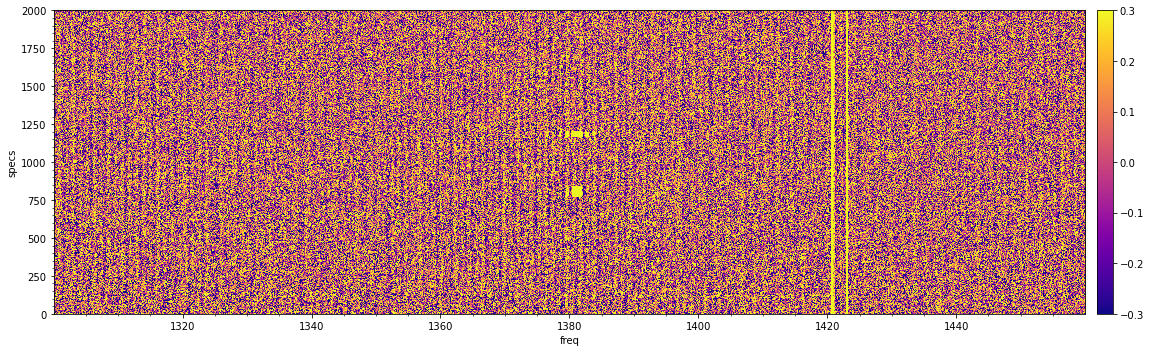

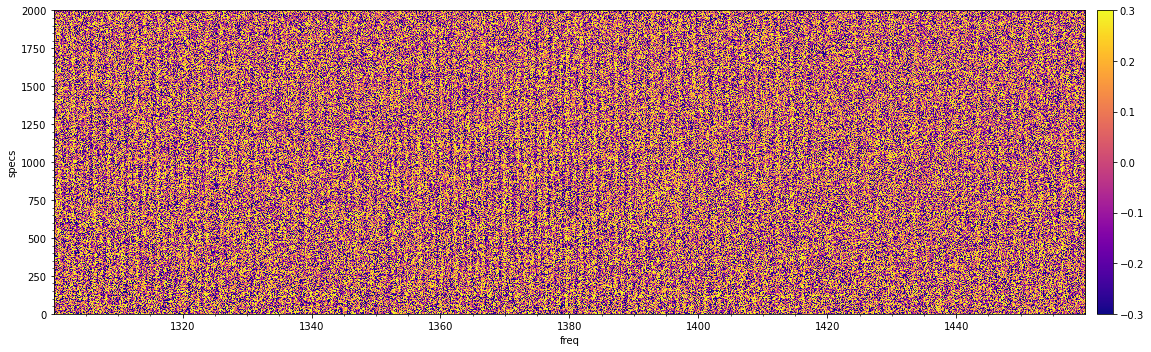

In [19]:
plot_waterfall(sub,data = data,vmin_max=[-.3,.3],cmap='plasma',figsize=(18,5))
plot_waterfall(sub,data = data_rep,vmin_max=[-.3,.3],cmap='plasma',figsize=(18,5))

# FFT remove 1MHz ripples

* --fft_method: 目前只提供rfft，mean和median的方法见‘cli_baseline_mean去基线‘

* --amp_thr_mean_factor: fourier空间的平均振幅大于阈值的模，会被识别为已知的几种驻波。这里输入的是中值的倍数
* --amp_thr_factor: fourier空间的每一谱线的振幅大于阈值，会被选中为驻波一部分被去除。这里输入的是中值的倍数
* --chan_wide: 距离驻波的模的中心左右各(2 * chann - 1)个通道数的模，作为驻波的一部分被选中，这里为由于fourier空间中峰比较宽，多选一些
  --chan_narr: 同理，窄一些的
* --choose_method: 选择fourier模的方法，'all'或者'interpolate'
  
* --rip_base: 去除基频(实空间的常数)
* --rip_1mhz: fft去除1.08mhz 驻波，单镜都有的
* --rip_2mhz: fft去除1.92mhz 驻波，只有M06 yy有
* --rip_0_04mhz: fft去除0.039mhz 驻波，很弱的偏振驻波，由于光纤反射

* --fft_ylim: 画fft模的上下限 

* --fill_rfi: 对输入的rfi区域，可以填nan或者保持原样。对应'nan','rfi'。需要注意只有输入对应RFI文件才能填nan。

In [20]:
fftf = FFT(data_rep, freq)
x = fftf.x
amp_data = fftf.amp
amp = np.mean(amp_data,axis=0)
amp_off = np.mean(amp_data[~is_on],axis=0)

(24.0, 27.0)

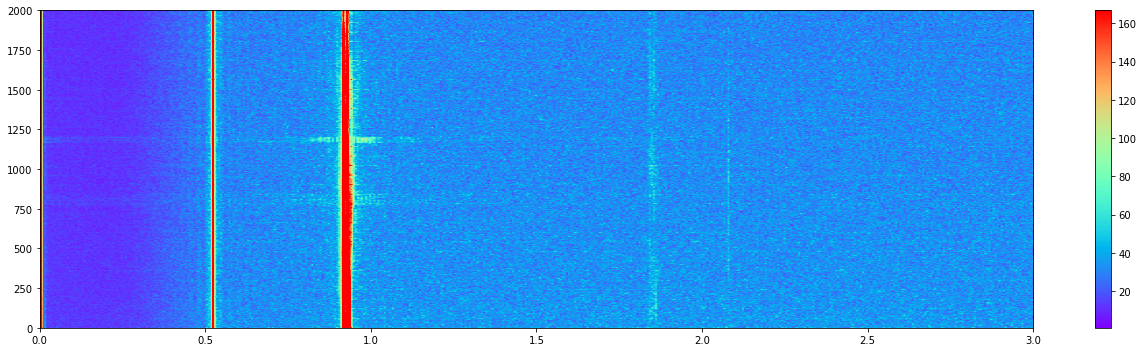

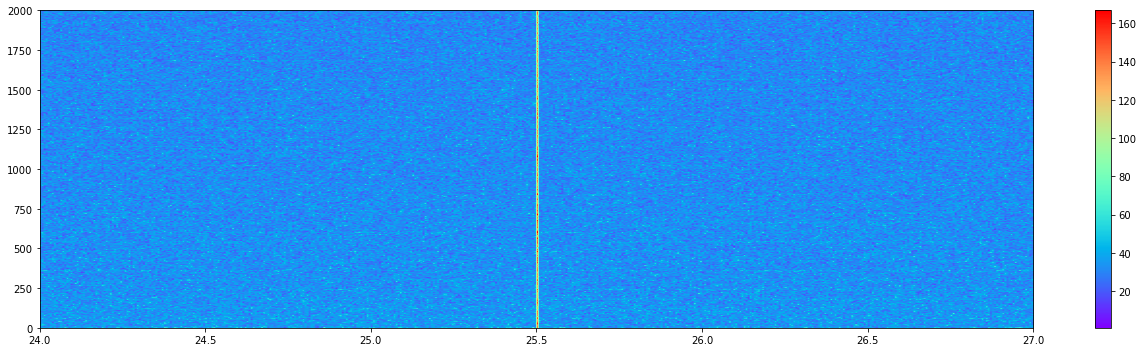

In [22]:
plt.figure(figsize=(18,5))
vmin,vmax = percent_vminmax(amp_data,percent = .999)
plt.imshow(amp_data,origin='lower',aspect='auto',extent=(x[0],x[-1],0,amp_data.shape[0]),
        vmin=vmin,vmax=vmax,cmap='rainbow')

plt.tight_layout()
plt.colorbar()
plt.xlim(0,3)

plt.figure(figsize=(18,5))
vmin,vmax = percent_vminmax(amp_data,percent = .999)
plt.imshow(amp_data,origin='lower',aspect='auto',extent=(x[0],x[-1],0,amp_data.shape[0]),
        vmin=vmin,vmax=vmax,cmap='rainbow')

plt.tight_layout()
plt.colorbar()
plt.xlim(24,27)

先通过平均所有振幅，决定该波束存在哪些驻波

In [23]:
def test_amp_mean(x,amp_thr_mean_factor,):
    rip_1mhz = True;rip_2mhz = True;rip_0_04mhz = True
    amp_thr = np.nanmedian(amp) * amp_thr_mean_factor
    # 1 mhz
   
    loc1,sw_1mhz,rip_1mhz = find_loc(amp,x,amp_thr,rip_mhz=rip_1mhz,xlim=[.90,.95])
    loc1_,sw_1mhz_,_ = find_loc(amp,x,amp_thr,rip_mhz=rip_1mhz,xlim=[1.8,1.9])
    if loc1_ is None:
        loc1s = np.array([loc1])
    else:
        loc1s = np.array([loc1,loc1_])
    # 2 mhz
    loc2,sw_2mhz,rip_2mhz = find_loc(amp,x,amp_thr,rip_mhz=rip_2mhz,xlim=[.5,.6])
    # 0.04 mhz
    loc0_04,sw_0_04mhz,rip_0_04mhz = find_loc(amp,x,amp_thr,rip_mhz=rip_0_04mhz,xlim=[25,26])
    
    select = np.full(x.shape,np.nan)
    
    if rip_1mhz:
        select[loc1s] = 30
    if rip_2mhz:
        select[loc2] = 30
    if rip_0_04mhz:
        select[loc0_04] = 30
    return select
def test_amp_mean_thr(x,amp_thr_mean_factor):
    amp_thr = np.nanmedian(amp) * amp_thr_mean_factor
    amp_thr = np.full(len(x),amp_thr)
    return amp_thr

改变这里的amp_thr_mean_factor，选择的驻波数量会变化(print的变化在log窗口里)

In [24]:
%matplotlib ipympl
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(211) 
ax.set_xlim(-.01,2)
iplt.plot(x,amp, label = 'amp mean')
controls = iplt.plot(x,test_amp_mean,'^',amp_thr_mean_factor=np.arange(1,3,0.02),
                     xlim=[-.01,2],ylim=[0,150],label='selected')
iplt.plot(x,test_amp_mean_thr,'k--',controls=controls,
                     alpha=.5,xlim=[-.01,2],ylim=[0,150],label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('k [$\mu$s]')

ax = fig.add_subplot(212) 
iplt.plot(x,amp, label = 'amp mean')
iplt.plot(x,test_amp_mean,'^',controls=controls,
                     xlim=[25,26],ylim=[0,150],label='selected')
iplt.plot(x,test_amp_mean_thr,'k--',controls=controls,
                      alpha=.5,xlim=[25,26],ylim=[0,150],label = 'thr')
ax.set_xlim(25,26)
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('k [$\mu$s]')

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

find ripple 1.09586 MHz,0.91252 mu s,locate in 146
find ripple 0.54053 MHz,1.85005 mu s,locate in 296
find ripple 1.92766 MHz,0.51876 mu s,locate in 83
find ripple 0.03921 MHz,25.50063 mu s,locate in 4080


VBox()

find ripple 1.09586 MHz,0.91252 mu s,locate in 146
find ripple 0.54053 MHz,1.85005 mu s,locate in 296
find ripple 1.92766 MHz,0.51876 mu s,locate in 83
find ripple 0.03921 MHz,25.50063 mu s,locate in 4080


Text(0.5, 0, 'k [$\\mu$s]')

从平均的fourier模，可以看出明显的几种驻波，2mhz、1mhz、0.04mhz和0.92mhz周期RFI

同理，决定单条谱线适用的阈值倍数amp_thr_factor和取模通道数，chan_wide,chan_narr。这里可视化测试off的谱线举例

In [25]:
tn = np.arange(data.shape[0])[~is_on][0]
def test_amp(x,amp_thr_mean_factor,amp_thr_factor,chan_wide,chan_narr):
    rip_1mhz = True;rip_2mhz = True;rip_0_04mhz = True
    amp_thr = np.nanmedian(amp) * amp_thr_mean_factor
    amp_thr_off = np.nanmedian(amp_off) * amp_thr_factor
    
    # 1 mhz
    loc1,sw_1mhz,rip_1mhz = find_loc(amp,x,amp_thr,rip_mhz=rip_1mhz,xlim=[.90,.95],Print=False)
    loc1_,sw_1mhz_,_ = find_loc(amp,x,amp_thr,rip_mhz=rip_1mhz,xlim=[1.8,1.9],Print=False)
    if loc1_ is None:
        loc1s = np.array([loc1])
    else:
        loc1s = np.array([loc1,loc1_])
    # 2 mhz
    loc2,sw_2mhz,rip_2mhz = find_loc(amp,x,amp_thr,rip_mhz=rip_2mhz,xlim=[.5,.6],Print=False)
    # 0.04 mhz
    loc0_04,sw_0_04mhz,rip_0_04mhz = find_loc(amp,x,amp_thr,rip_mhz=rip_0_04mhz,xlim=[25,26],Print=False)
    
    # select which components?
    use = np.zeros_like(x,dtype = 'bool')
    use_1mhz = np.zeros_like(x,dtype = 'bool')
    use_2mhz = np.zeros_like(x,dtype = 'bool')
    use_0_04mhz = np.zeros_like(x,dtype = 'bool')
    if rip_1mhz:
        for s1 in range(len(loc1s)):
            use_1mhz |= (np.abs(np.arange(len(x))-loc1s[s1]) < chan_wide)
        use[use_1mhz] = True
    if rip_2mhz:
        use_2mhz = (np.abs(np.arange(len(x))-loc2) < chan_wide)
        use[use_2mhz] = True
    if rip_0_04mhz:
        use_0_04mhz = (np.abs(np.arange(len(x))-loc0_04) < chan_narr)
        use[use_0_04mhz] = True
    select = np.full(x.shape,0)   
    use_amp = use  & (amp_data[tn] > amp_thr_off)
    select[use_amp] = amp_data[tn][use_amp]
    
    return select
    
def test_amp_thr(x,amp_thr_mean_factor,amp_thr_factor,chan_wide,chan_narr):
    amp_thr_off = np.nanmedian(amp_off) * amp_thr_factor
    amp_thr_off = np.full(len(x),amp_thr_off)
    return amp_thr_off

In [26]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(211) 
ax.set_xlim(-.01,2)
iplt.plot(x,amp_data[tn], label = 'amp mean')
controls = iplt.plot(x,test_amp,amp_thr_mean_factor=np.arange(1,3,0.02),amp_thr_factor=np.arange(1,3,0.02),
                     chan_wide=np.arange(1,11),chan_narr=np.arange(1,7),
                     xlim=[-.01,2],ylim=[0,150],label='selected')
iplt.plot(x,test_amp_thr,'k--',controls=controls,
                     alpha=.5,xlim=[-.01,2],ylim=[0,150],label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('k [$\mu$s]')

ax = fig.add_subplot(212) 
iplt.plot(x,amp_data[tn], label = 'amp mean')
iplt.plot(x,test_amp,controls=controls,
                     xlim=[25,26],ylim=[0,150],label='selected')
iplt.plot(x,test_amp_thr,'k--',controls=controls,
                      alpha=.5,xlim=[25,26],ylim=[0,150],label = 'thr')
ax.set_xlim(25,26)
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('k [$\mu$s]')

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

VBox()

Text(0.5, 0, 'k [$\\mu$s]')

下图为1mhz驻波的相位,noise on的相位有所漂移

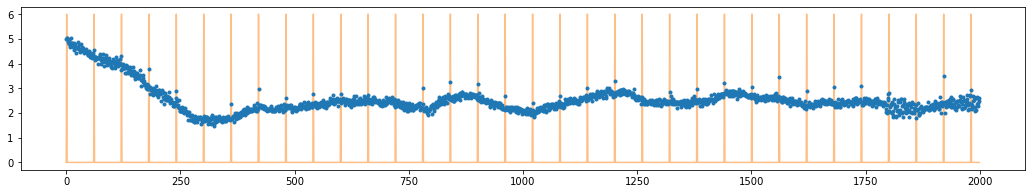

In [28]:
%matplotlib inline
phi = deepcopy(fftf.phi)
phi[phi<0] = phi[phi<0] +2 * np.pi
plt.figure(figsize=(18,3))
plt.plot(is_on*6,c='C1',alpha=.5)
plt.plot(np.arange(data_rep.shape[0]),phi[:,146],'.')

对于测试数据，我选择了以下参数.fit_args['choose_method']有选择所有模'all'和线性插值'interpolate'两种方式，可以分别尝试效果。

In [29]:
fit_args = {}
fit_args['chan_wide'] = 5
fit_args['chan_narr'] = 3
fit_args['amp_thr_mean_factor'] = 1.05
fit_args['amp_thr_factor'] = 1.4
fit_args['rip_base'] = True
fit_args['rip_1mhz'] = True
fit_args['rip_2mhz'] = True
fit_args['rip_0_04mhz'] = True
fit_args['fft_ylim'] = [-5,160]
fit_args['choose_method'] = 'all'

In [31]:
whole_rfi = np.all(is_rfi,axis = 1)
not_rfi_num = np.arange(data.shape[0])[~whole_rfi]
is_rfi_num = np.arange(data.shape[0])[whole_rfi]
ori_shape = data.shape

standing waves

INFO: Fit baseline ripple with rfft method ... [baseline_2]
mean amp thr:33.938, amp thr on:69.994, amp thr off:44.821
find ripple 1.09586 MHz,0.91252 mu s,locate in 146
find ripple 0.54053 MHz,1.85005 mu s,locate in 296
find ripple 1.92766 MHz,0.51876 mu s,locate in 83
find ripple 0.03921 MHz,25.50063 mu s,locate in 4080
Finished ifft.


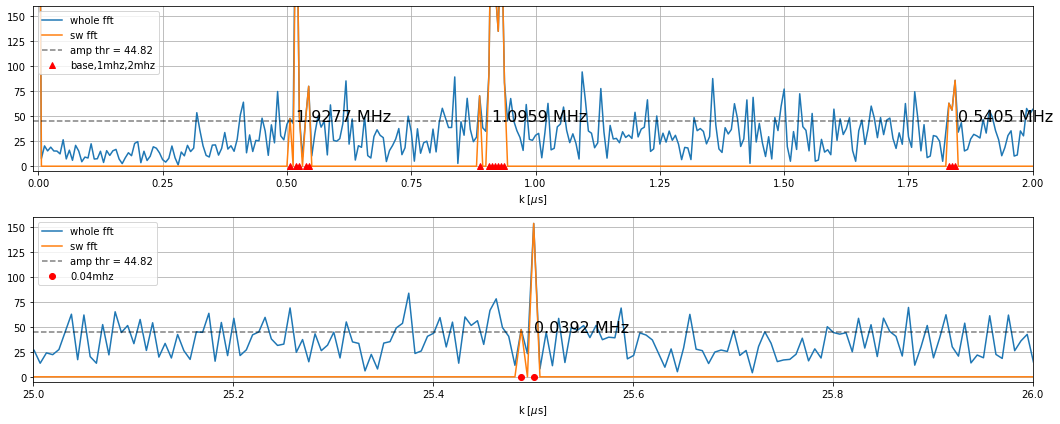

In [32]:
%matplotlib inline
sw = fit_ripple(data_rep,freq,'rfft', is_rfi_num,not_rfi_num,ori_shape,plot = True,
                   is_on = is_on, **fit_args)

remove standing waves

In [33]:
rmsw_data = data - sw

下面可以画一下单条谱线的效果，std有所降低

In [34]:
from hifast.utils.misc import smooth1d
from markRFI import std,real_std

0.2670239319646883 0.25691979989996677 0.26033549550102403 1.039327961755597 1.013294793170426


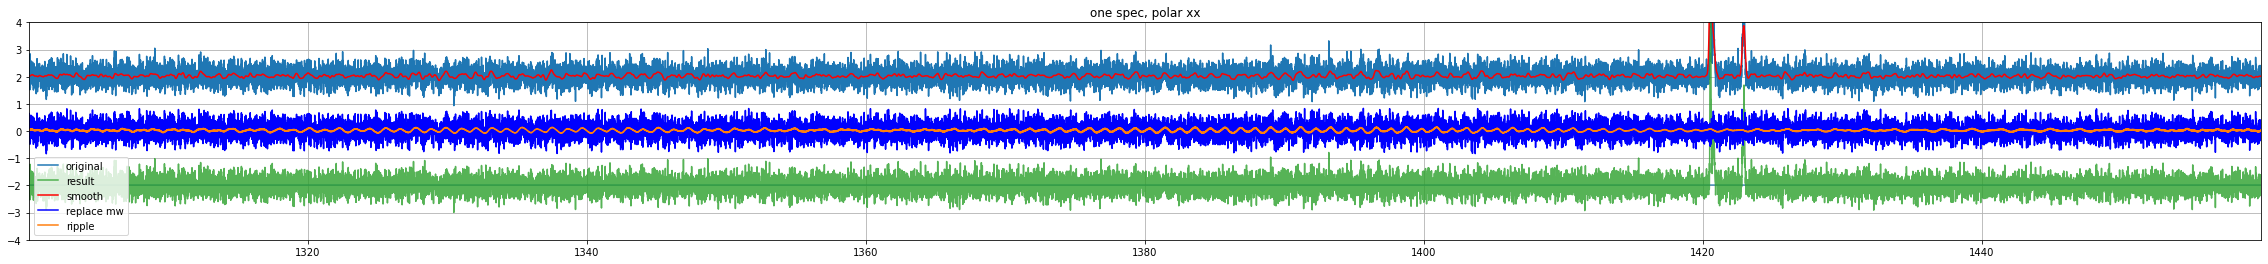

In [35]:
fig = plt.figure(figsize=(40,4))
ax = fig.add_subplot(111)
ax.hlines([0,-2],freq[0],freq[-1],alpha = .8)
ax.plot(freq,data[tn]+2,label='original')
ax.plot(freq,rmsw_data[tn] -2,label='result',c='C2',alpha = .8)
ax.plot(freq,smooth1d(data[tn],method='gaussian', sigma=10) +2,'r',label = 'smooth')
ax.plot(freq,data_rep[tn],'b',label='replace mw')
ax.plot(freq,sw[tn],c= 'C1',label='ripple')
ax.set_xlim(freq[0],freq[-1])
ax.set_ylim(-4,4) 
ax.grid();ax.legend();ax.set_title(f'one spec, polar xx')

spec = data[tn]
std_range = [1380,1382]
ori = std(spec,freq,std_range)
real = real_std(spec,freq,10,std_range)
ret = std(rmsw_data[tn],freq,std_range)
print(ori,real,ret,ori/real,ret/real)

# 平均值/中值谱线去基线(cli_baseline_mean)

* --sub_method: mean或median，取平均或中值前后若干条谱线作为基线
* --nspec: 平均谱线条数，默认10条。过少容易损失信号，过多容易驻波变化了。

输出文件名含mean_bld/med_bld

```
python cli_baseline_mean.py $fname --outdir $outdir \
        --sub_method mean --nspec 100 --frange 1330 1360 \
        --plot --ylim -1 .5 --vmin_max -.05 .05 -f --keep_polar --fill_rfi nan || exit 1 
```

In [36]:
sep = h5py.File('/data/inspur_disk01/userdir/jyj/FAST/jingyj/M31_snapshot/data/M31_SnapShot_6_snapshot-M06_W-20210730-specs_T.hdf5','r')
data_sep = get_data(sep,polar='yy')[:][:2000]

In [37]:
sw_mean = fit_ripple(data_sep, method='mean',nspec=10)
rmsw_data_mean = data_sep - sw_mean

INFO: Fit baseline ripple with mean method ... [baseline_2]
mean 10


100%|██████████| 2000/2000 [00:01<00:00, 1112.83it/s]


0.2670239319646883 0.25691979989996677 0.2505475604703688 1.039327961755597 0.9751975541313708


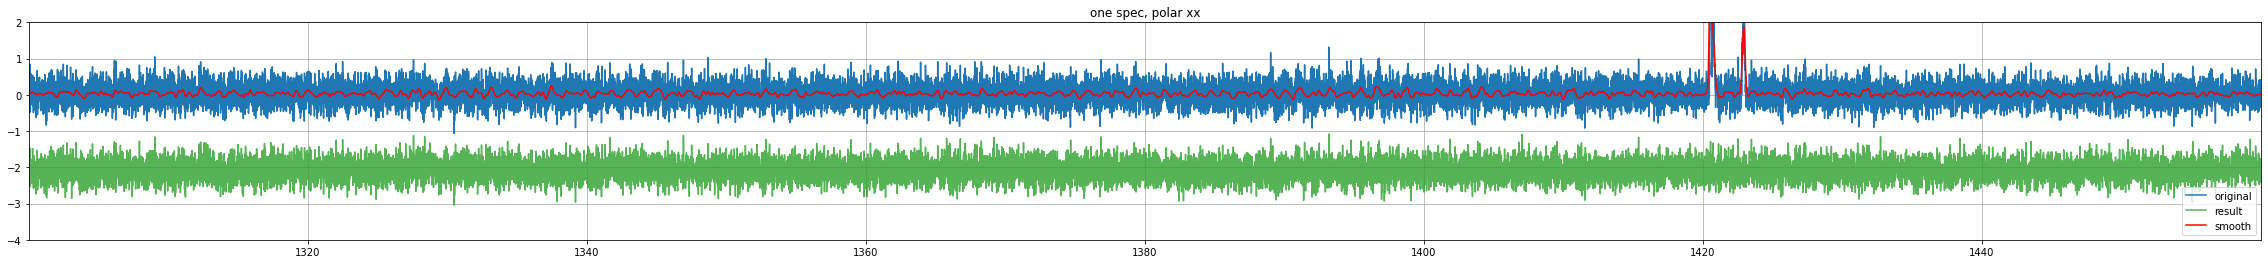

In [38]:
tn = 0
fig = plt.figure(figsize=(40,4))
ax = fig.add_subplot(111)
ax.plot(freq,data[tn],label='original')
ax.plot(freq,rmsw_data_mean[tn] -2,label='result',c='C2',alpha = .8)
ax.plot(freq,smooth1d(data[tn],method='gaussian', sigma=10) ,'r',label = 'smooth')
#ax.plot(freq,sw_mean[tn],c= 'C1',label='ripple')
ax.set_xlim(freq[0],freq[-1])
ax.set_ylim(-4,2) 
ax.grid();ax.legend();ax.set_title(f'one spec, polar xx')

spec = data[tn]
std_range = [1380,1382]
ori = std(spec,freq,std_range)
real = real_std(spec,freq,10,std_range)
ret = std(rmsw_data_mean[tn],freq,std_range)
print(ori,real,ret,ori/real,ret/real)

目前有周期RFI，而且平均太多驻波相位会有变化。noise on与off变化明显，所以不应平均太多。太少会失去源的流量。需要注意，由于不同谱线基线不同，还需要使用cli_baseline.py多项式去一次基线。